In [1]:
import os
import glob
import yaml
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from matplotlib.patches import Rectangle


Seed = 42
random.seed(Seed)
np.random.seed(Seed)


with open('/kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/data.yaml','r') as f:
    yaml_summary = yaml.safe_load(f)
dataset_img_path = '/kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/images'
train_img_direction = os.path.join(dataset_img_path,'train')
val_imd_direction = os.path.join(dataset_img_path,'val')
classes = yaml_summary['names']

Сбор путей к тренировочным и валидационным изображениям

In [2]:
imgage_formats = ['*.jpg','*.img','*.jpeg','*.png']
def img_coll(folder):
    folder = Path(folder)
    paths = []
    for i in imgage_formats:
        paths.extend(folder.rglob(i))
    return sorted(paths)
train_img = img_coll(train_img_direction)
val_img = img_coll(val_imd_direction)
print(f'кол-во train изображений:{len(train_img)},валидационных:{len(val_img)}')

кол-во train изображений:8208,валидационных:2051


Парсинг YOLO-разметки и создание общего DataFrame

In [3]:
def img2labels(img_path):
    parts = list(Path(img_path).parts)
    if 'images' in parts:
        idx = parts.index('images')
        parts[idx] = 'labels'
        return Path(*parts).with_suffix('.txt')
    return img_path.with_suffix('.txt')

def read_yolo(label_path):
    records = []
    if not Path(label_path).exists():
        return records
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:5])   
            records.append({
                'class_id': cls_id,              
                'x_center': x,
                'y_center': y,
                'bbox_width': w,
                'bbox_height': h,
                'bbox_area': w * h,
            })
    return records

def build_df(image_paths, split_name):
    rows = []
    for img_path in image_paths:                  
        img = Image.open(img_path)                
        w, h = img.size
        
        label_path = img2labels(img_path)
        labels = read_yolo(label_path)            
        
        if not labels:
            rows.append({
                'split': split_name,
                'image_path': str(img_path),
                'image_width': w,
                'image_height': h,
                'has_label': False,
                'num_boxes_in_image': 0,
            })
        else:
            for lab in labels:
                rows.append({
                    'split': split_name,
                    'image_path': str(img_path),   
                    'image_width': w,
                    'image_height': h,
                    'has_label': True,
                    'num_boxes_in_image': len(labels),
                    'class_id': lab['class_id'],
                    'class_name': classes[lab['class_id']],
                    'x_center': lab['x_center'],
                    'y_center': lab['y_center'],
                    'bbox_width': lab['bbox_width'],
                    'bbox_height': lab['bbox_height'],
                    'bbox_area': lab['bbox_area'],
                    'bbox_width_px': lab['bbox_width'] * w,
                    'bbox_height_px': lab['bbox_height'] * h,
                    'bbox_area_px': lab['bbox_width'] * w * lab['bbox_height'] * h,
                })
    return pd.DataFrame(rows)



df_train = build_df(train_img, 'train')
df_val = build_df(val_img, 'val')
df_all = pd.concat([df_train, df_val], ignore_index=True)

df_all.info()                                    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20276 entries, 0 to 20275
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   split               20276 non-null  object 
 1   image_path          20276 non-null  object 
 2   image_width         20276 non-null  int64  
 3   image_height        20276 non-null  int64  
 4   has_label           20276 non-null  bool   
 5   num_boxes_in_image  20276 non-null  int64  
 6   class_id            20276 non-null  int64  
 7   class_name          20276 non-null  object 
 8   x_center            20276 non-null  float64
 9   y_center            20276 non-null  float64
 10  bbox_width          20276 non-null  float64
 11  bbox_height         20276 non-null  float64
 12  bbox_area           20276 non-null  float64
 13  bbox_width_px       20276 non-null  float64
 14  bbox_height_px      20276 non-null  float64
 15  bbox_area_px        20276 non-null  float64
dtypes: b

Статистика: сколько объектов каждого класса в train / val

In [4]:
class_counts = df_all[df_all['has_label']].groupby(['split', 'class_name']).size().reset_index(name='num_boxes')
class_counts['percentage'] = class_counts.groupby('split')['num_boxes'].transform(lambda x: 100 * x / x.sum())


print(class_counts.to_string(index=False))

split class_name  num_boxes  percentage
train       BMFO       1334    8.242709
train        CFO       1409    8.706130
train         CS       2042   12.617400
train         HB       2275   14.057093
train         MB       1983   12.252842
train         OP       1432    8.848245
train         SC       1308    8.082056
train         SH        746    4.609491
train         SP       3655   22.584034
  val       BMFO        346    8.455523
  val        CFO        423   10.337243
  val         CS        448   10.948192
  val         HB        608   14.858260
  val         MB        546   13.343109
  val         OP        338    8.260020
  val         SC        285    6.964809
  val         SH        169    4.130010
  val         SP        929   22.702835


Распределение объектов по размеру (small/medium/large)

In [5]:
def size_count(area_px):
    if area_px < 32*32:
        return 'small'
    if area_px < 96*96:
        return 'medium'
    else:
        return 'large'
df_all['size_cat'] = df_all['bbox_area_px'].apply(size_count)
size_counts = df_all[df_all['has_label']].groupby(['split', 'size_cat']).size().reset_index(name='num_boxes')
print(size_counts)


   split size_cat  num_boxes
0  train    large        729
1  train   medium       4600
2  train    small      10855
3    val    large        176
4    val   medium       1197
5    val    small       2719


Установка ultralytics и импорт YOLO

In [7]:
!pip install -q ultralytics
from ultralytics import YOLO
import torch
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.0 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Обучение YOLOv8s на датасете PCB-дефектов (50 эпох) 
Наиболее частый размер изображения исходного датасета-226х226 поэтому было выбрано imgsz=640 что увеличит изображение но не сильно увеличит время обучения. 

In [10]:
model = YOLO('yolov8s.pt')


results = model.train(
    data='/kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/data.yaml',          # путь к data.yaml
    epochs=50,                    
    imgsz=640,                    
    batch=16,                     
    device=device,                
    workers=4,
    patience=10,                  
    project='yolo_pcb',           
    name='exp1',                  
    exist_ok=True,                
    pretrained=True,
    optimizer='auto',
    verbose=True,
)

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, op

Оценка лучшей модели на валидации + сохранение матрицы ошибок

In [12]:
best_model = YOLO('/kaggle/working/runs/detect/yolo_pcb/exp1/weights/best.pt')


val_metrics = best_model.val(
    data='/kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/data.yaml',
    split='val',          
    batch=16,
    imgsz=640,
    device=device,
    plots=True,           
    save_json=True,       
)


print(f"mAP50: {val_metrics.box.map50:.4f}")
print(f"mAP50-95: {val_metrics.box.map:.4f}")
print(f"Precision (macro): {val_metrics.box.mp:.4f}")
print(f"Recall (macro): {val_metrics.box.mr:.4f}")

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 17.8±9.9 MB/s, size: 8.6 KB)
val: Scanning /kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/labels/val... 2051 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2051/2051 740.6it/s 2.8s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 129/129 4.6it/s 28.1s0.2s
                   all       2051       4092      0.816      0.812      0.845      0.506
                    SH        126        169      0.828      0.846      0.873      0.573
                    SP        430        929      0.846      0.781      0

Сравнение верных аннотаций дефектов(Ground truth) и предсказания(prediction)


image 1/1 /kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/images/val/0014089.jpg: 640x640 1 HB, 1 BMFO, 16.3ms
Speed: 2.5ms preprocess, 16.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/images/val/0032075.jpg: 640x640 1 SP, 16.1ms
Speed: 1.8ms preprocess, 16.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/images/val/0032448.jpg: 640x640 1 SC, 16.1ms
Speed: 1.9ms preprocess, 16.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/images/val/0034013.jpg: 640x640 2 SCs, 1 MB, 16.1ms
Speed: 1.8ms preprocess, 16.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

imag

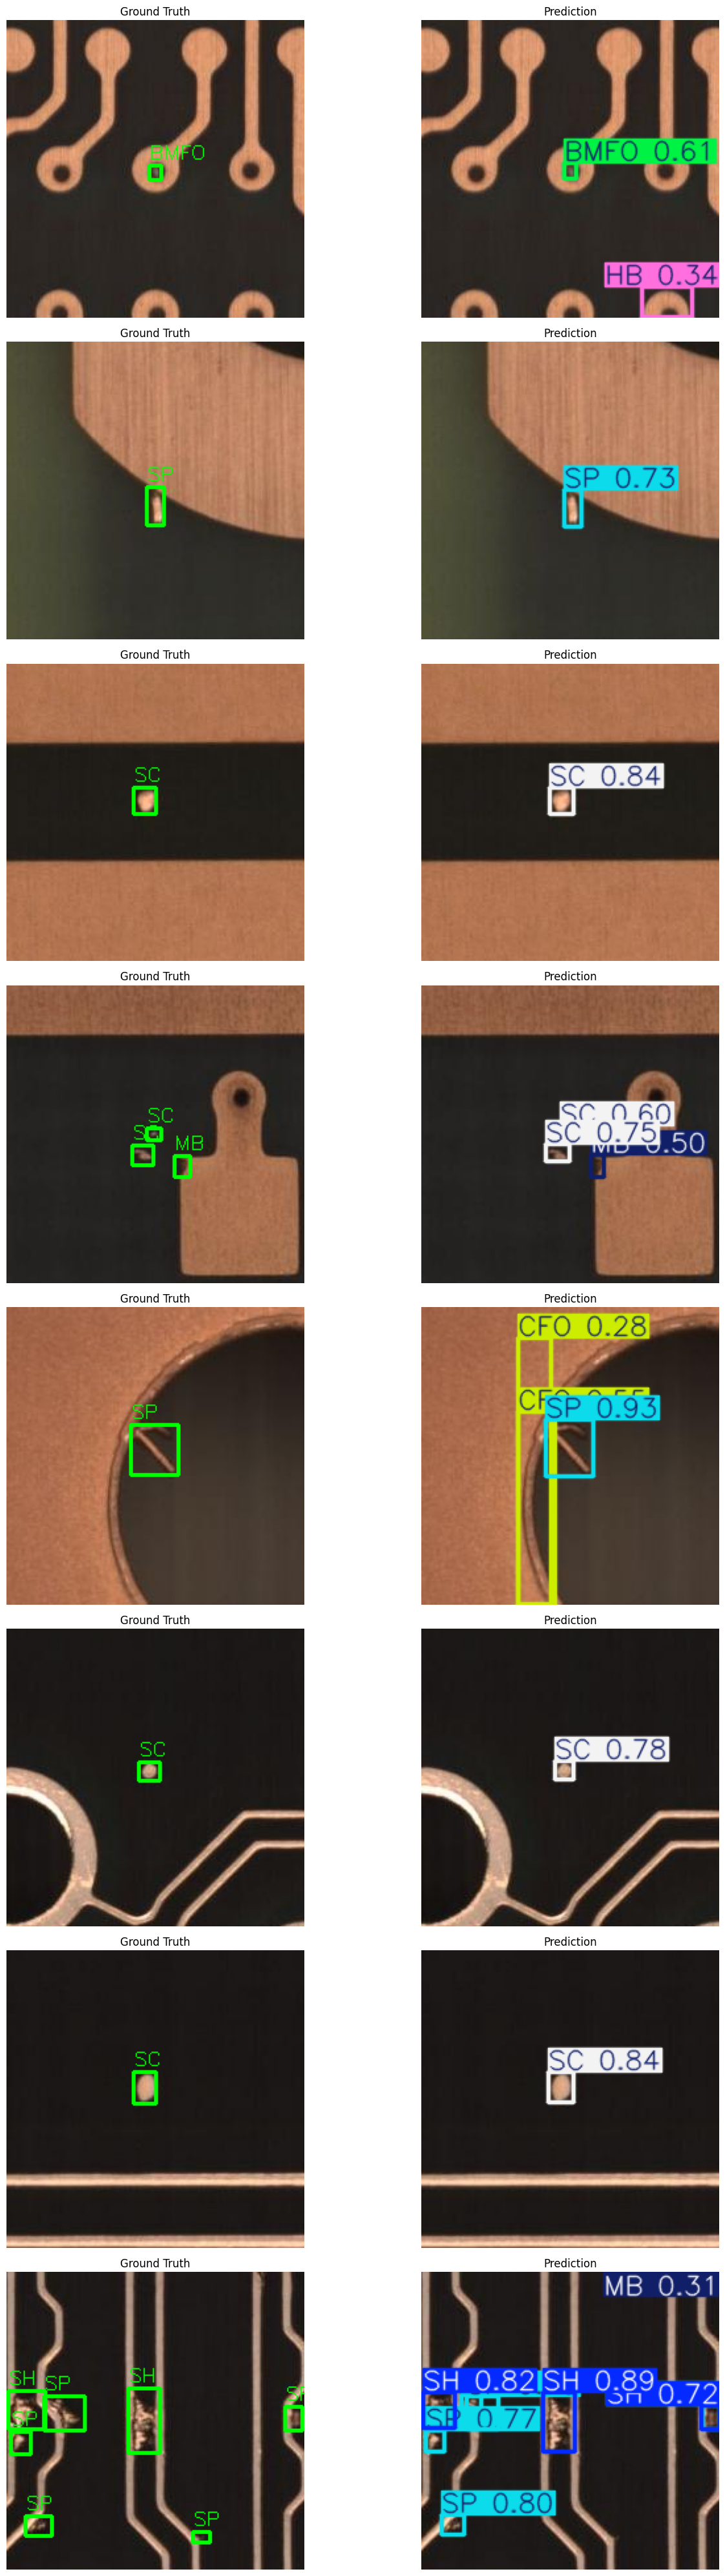

In [27]:
def draw_gt(img, boxes):
    h, w, _ = img.shape
    for _, r in boxes.iterrows():
        x1 = int((r['x_center'] - r['bbox_width']/2) * w)
        y1 = int((r['y_center'] - r['bbox_height']/2) * h)
        x2 = int((r['x_center'] + r['bbox_width']/2) * w)
        y2 = int((r['y_center'] + r['bbox_height']/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, r['class_name'], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return img

def draw_pred(img, res):
    return cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)

val_imgs = sorted(glob.glob('/kaggle/input/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/DsPCBSD+/Data_YOLO/images/val/*.jpg'))[:8]

fig, axes = plt.subplots(8, 2, figsize=(15, 40))
for i, p in enumerate(val_imgs):
    img_bgr = cv2.imread(p)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gt = df_all[(df_all['image_path'] == p) & df_all['has_label']]
    axes[i, 0].imshow(draw_gt(img_rgb.copy(), gt))
    axes[i, 0].set_title('Ground Truth')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(draw_pred(img_bgr, model(p)))
    axes[i, 1].set_title('Prediction')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('compare.png')
plt.show()

Детальные метрики (Precision, Recall, mAP) для каждого класса

In [15]:
metrics = val_metrics.box
for i, cls_id in enumerate(metrics.ap_class_index):
    p = metrics.p[i]
    r = metrics.r[i]
    ap50 = metrics.all_ap[i, 0]          
    ap = metrics.all_ap[i].mean()        
    cls_name = classes[cls_id]
    print(f"{cls_name:>6} | P: {p:.3f} | R: {r:.3f} | mAP50: {ap50:.3f} | mAP50-95: {ap:.3f}")

    SH | P: 0.828 | R: 0.846 | mAP50: 0.873 | mAP50-95: 0.573
    SP | P: 0.846 | R: 0.781 | mAP50: 0.836 | mAP50-95: 0.382
    SC | P: 0.792 | R: 0.827 | mAP50: 0.822 | mAP50-95: 0.503
    OP | P: 0.832 | R: 0.852 | mAP50: 0.903 | mAP50-95: 0.534
    MB | P: 0.861 | R: 0.767 | mAP50: 0.840 | mAP50-95: 0.409
    HB | P: 0.936 | R: 0.955 | mAP50: 0.984 | mAP50-95: 0.819
    CS | P: 0.711 | R: 0.712 | mAP50: 0.739 | mAP50-95: 0.453
   CFO | P: 0.721 | R: 0.686 | mAP50: 0.737 | mAP50-95: 0.415
  BMFO | P: 0.818 | R: 0.884 | mAP50: 0.875 | mAP50-95: 0.467


In [26]:
import shutil
import os
from IPython.display import FileLink, display


folder = '/kaggle/working/runs/detect/yolo_pcb/exp1'
zip_name = 'model_results.zip'


shutil.make_archive(zip_name.replace('.zip', ''), 'zip', folder)


display(FileLink(zip_name))

/kaggle/working/model_results.zip